In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import sys, os, time

sys.path.append('packages')

import crydberg as rd

# Generating system (fresh)

In [50]:
N = 10
n_networks = 100
n_thermalSamples = 100
n_samples = n_networks*n_thermalSamples
K = 1

# making fresh directory
dir_out = f'data/N{N}_K{K}'
os.makedirs(dir_out, exist_ok=True)

systems = rd.MagneticSystem(N, n_samples, K=K) # generating system
systems.align_m() # randomizing initial spin config. m0
systems.m = cp.broadcast_to(systems.m[0], (n_samples, N, 3)) # copying one m0 throughout all samples
np.save(f'{dir_out}/m0_N{N}_K{K}.npy', systems.m.get()) # saving m0

# setting Js of thermal samples batches with one J
J_toSet = []
for J in systems.J[:n_networks]:
    J_toSet.append(cp.broadcast_to(J, (n_thermalSamples, N, N)))
J_toSet = cp.array(J_toSet)
J_toSet = J_toSet.reshape(n_samples, N, N)
systems.J = J_toSet
del J_toSet # deleting buffer
np.save(f'{dir_out}/J_N{N}_K{K}.npy', systems.J.get()) # saving coupling matrices

# Running dynamics

In [51]:
dt = 0.1
n_burnSteps = 20000
n_steps = 1
T_vals = cp.linspace(0.2, 0.4, 20)
np.save(f'{dir_out}/T_vals.npy', T_vals.get())

steps = cp.arange(n_steps)

# running for each temperature
for T_idx, T in enumerate(T_vals):
    # burning-in system
    for i in range(n_burnSteps):
        systems.LLG_1stepSIB(dt, alpha=1, precession=0, T=T)
        print(f'\rProgress: {100*i/n_burnSteps}%     ', end='')
    
    # storing data
    history = []
    for i in range(n_steps):
        history.append(systems.m)
        systems.LLG_1stepSIB(dt, alpha=1, precession=0, T=T)
    history = cp.array(history).reshape(n_steps, n_networks, n_thermalSamples, N, 3)
    np.save(f'{dir_out}/history_N{N}_K{K}_T{T_idx}.npy', history.get())
    print(f'\r{T_idx + 1}/{T_vals.size} Done.          ')

1/20 Done.            
2/20 Done.            
3/20 Done.            
4/20 Done.            
5/20 Done.            
6/20 Done.            
7/20 Done.            
8/20 Done.            
9/20 Done.            
10/20 Done.           
11/20 Done.           
12/20 Done.           
13/20 Done.           
14/20 Done.           
15/20 Done.           
16/20 Done.           
17/20 Done.           
18/20 Done.           
19/20 Done.           
20/20 Done.           


# Continuing run

In [14]:
N = 10
n_networks = 100
n_thermalSamples = 100
n_samples = n_networks*n_thermalSamples
K = 1

# making fresh directory
dir_out = f'data/N{N}_K{K}_S3'
dir_initSrc = f'data/N{N}_K{K}_S2'
dir_JSrc = f'data/N{N}_K{K}_S1'
os.makedirs(dir_out, exist_ok=True)

systems = rd.MagneticSystem(N, n_samples, K=K) # generating system

# loading J
systems.J = cp.load(f'{dir_JSrc}/J_N{N}_K{K}.npy')

In [ ]:
dt = 0.1
n_burnSteps = 20000
n_steps = 1
T_vals = cp.linspace(0.2, 0.6, 20)
np.save(f'{dir_out}/T_vals.npy', T_vals.get())

steps = cp.arange(n_steps)

startIndex = 0
# running for each temperature
for T_idx, T in enumerate(T_vals):
    if T_idx < startIndex: 
        None
    else:
        # loading spins
        m0 = cp.load(f'{dir_initSrc}/history_N{N}_K{K}_T{T_idx}.npy')[-1,:,:,:,:]
        m0 = m0.reshape(n_samples, N, 3)
        systems.m = m0
        
        # burning-in system
        for i in range(n_burnSteps):
            systems.LLG_1stepSIB(dt, alpha=1, precession=0, T=T)
            print(f'\rProgress: {100*i/n_burnSteps}%     ', end='')
        
        # storing data
        history = []
        for i in range(n_steps):
            history.append(systems.m)
            systems.LLG_1stepSIB(dt, alpha=1, precession=0, T=T)
        history = cp.array(history).reshape(n_steps, n_networks, n_thermalSamples, N, 3)
        np.save(f'{dir_out}/history_N{N}_K{K}_T{T_idx}.npy', history.get())
        print(f'\r{T_idx + 1}/{T_vals.size} Done.          ')

# Edwards-Anderson parameter

In [4]:
EA = []
for T_idx, T in enumerate(T_vals):
    history = np.load(f'{dir_out}/history_N{N}_K{K}_T{T_idx}.npy')
    EA_T = np.mean(np.mean(history, axis=2)**2, axis=(0,1,2))
    EA.append(EA_T)
EA = np.array(EA)
np.save(f'{dir_out}/EA_N{N}_K{K}.npy', EA)

EA2 = []
for T_idx, T in enumerate(T_vals):
    history = np.load(f'{dir_out}/history_N{N}_K{K}_T{T_idx}.npy')
    EA2_T = np.mean(np.mean(history, axis=2)**4, axis=(0,1,2))
    EA2.append(EA2_T)
EA2 = np.array(EA2)
np.save(f'{dir_out}/EA2_N{N}_K{K}.npy', EA2)

In [5]:
U = (3 - EA2/EA**2)/2
np.save(f'{dir_out}/U_N{N}_K{K}.npy', U)

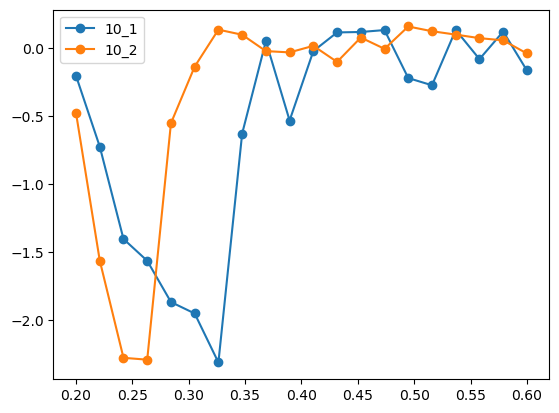

In [6]:
plt.plot(T_vals.get(), np.load('data/N10_K1/U_N10_K1.npy')[:,2], marker='o', label='10_1')
plt.plot(T_vals.get(), np.load('data/N10_K1_S2/U_N10_K1.npy')[:,2], marker='o', label='10_2')
plt.legend()

# Correlation

In [10]:
N = 10
K = 1
dir_initSrc = f'data/N{N}_K{K}'
dir_out     = f'data/N{N}_K{K}_S2'

m0 = np.load(f'{dir_initSrc}/m0_N{N}_K{K}.npy')
history = np.load(f'{dir_out}/history_N{N}_K{K}_T1.npy')
history_shape = history.shape
history = history.reshape(history_shape[1]*history_shape[2], history_shape[3], history_shape[4])

In [11]:
corr = np.mean(m0*history, axis=(0,1))

In [12]:
corr

array([-0.00138319,  0.00071676,  0.01443364])